# Examen Final — Machine Learning I
## Predicción del precio de diamantes: EDA, preprocesamiento sin *leakage*, análisis no supervisado y modelado supervisado

| | |
|---|---|
| **Estudiante** | Michele Castro Osorio |
| **Carrera** | Ingeniería en Inteligencia Artificial |
| **Asignatura** | Machine Learning I |
| **Profesor** | Danilo Alberto Gómez |
| **Tipo de evaluación** | Trabajo de desarrollo individual (30% de la asignatura) |
| **Fecha** | Septiembre de 2026 |

---

## 1. Declaración del dataset

| Campo | Detalle |
|---|---|
| **Nombre del dataset** | Diamonds |
| **Fuente** | Kaggle — *Diamonds* (`shivam2503/diamonds`). Conjunto clásico derivado del paquete `ggplot2` de R. |
| **URL pública verificable** | https://www.kaggle.com/datasets/shivam2503/diamonds |
| **URL de descarga directa (espejo con certificado válido, usado para reproducibilidad)** | https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv |
| **Número de filas** | 53 940 observaciones |
| **Número de columnas** | 10 (9 variables predictoras + 1 variable objetivo) |
| **Variable objetivo** | `price` — precio del diamante en dólares estadounidenses (USD) |
| **Tipo de tarea** | **Regresión** (la variable objetivo es continua) |

**¿Por qué este dataset?** Cumple con holgura los requisitos exigidos: tiene **53 940 observaciones** (≥ 500), **9 variables predictoras** (≥ 6) de las cuales **6 son numéricas continuas** (`carat`, `depth`, `table`, `x`, `y`, `z`) y **3 son categóricas** (`cut`, `color`, `clarity`), lo que me permite ejercitar de forma real todo el `ColumnTransformer` (imputación, escalado, `OrdinalEncoder` y `OneHotEncoder`). Además no pertenece a la lista de datasets prohibidos (Iris, Titanic, Boston, Breast Cancer, Digits, Wine, Diabetes). Es un problema de negocio concreto y comprensible: **estimar el precio justo de un diamante a partir de sus características físicas y de calidad**, útil para tasación, control de inventario y detección de precios anómalos en una joyería.

> **Descripción de las variables**
> - `carat`: peso del diamante en quilates (numérica continua).
> - `cut`: calidad del tallado — *Fair < Good < Very Good < Premium < Ideal* (categórica **ordinal**).
> - `color`: color del diamante, de *D* (mejor, incoloro) a *J* (peor) (categórica).
> - `clarity`: claridad/pureza — *I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF* (categórica **ordinal**).
> - `depth`: profundidad total en % = z / mean(x, y) (numérica continua).
> - `table`: ancho de la cara superior respecto al punto más ancho, en % (numérica continua).
> - `x`, `y`, `z`: dimensiones físicas (largo, ancho, alto) en mm (numéricas continuas).
> - `price`: **variable objetivo**, precio en USD (numérica continua).

## Mapa de este notebook respecto a la rúbrica

- **C1 — EDA + Preprocesamiento + No Supervisado (25 pts):** pasos 4 a 15.
- **C2 — Modelado Supervisado (35 pts):** pasos 16 a 23.
- **C3 — Interpretación + Conclusiones + Código/GitHub (20 pts):** pasos 24 a 29.
- **C4 — Presentación en video (20 pts):** ver `GUION_VIDEO.md`.

Todas las figuras se guardan automáticamente en la carpeta `figures/` con `dpi=150`, tal como exige la rúbrica.

## C1 · EDA, Preprocesamiento y Análisis No Supervisado

In [1]:
# --- Librerías ---
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                 # semilla global para reproducibilidad
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

os.makedirs("figures", exist_ok=True)
def guardar(nombre):
    "Guarda la figura activa en figures/ con dpi=150 (requisito de la rúbrica)."
    plt.savefig(f"figures/{nombre}", dpi=150, bbox_inches="tight")

print("Entorno listo. Versiones principales:")
import sklearn
print("  numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

Entorno listo. Versiones principales:
  numpy 2.4.4 | pandas 3.0.2 | scikit-learn 1.9.0


### Paso 4 — Carga del dataset y exploración inicial

Cargo los datos con `pandas` desde el CSV local incluido en el repositorio (`data/diamonds.csv`); si no estuviera disponible, hago *fallback* a la URL pública. Luego ejecuto `shape`, `dtypes`, `info()`, `describe()` y `head()`.

In [2]:
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
try:
    df = pd.read_csv("data/diamonds.csv")
    print("Cargado desde archivo local: data/diamonds.csv")
except FileNotFoundError:
    df = pd.read_csv(URL)
    print("Cargado desde URL pública.")

TARGET = "price"
print("\nDimensiones (df.shape):", df.shape)
df.head()

Cargado desde archivo local: data/diamonds.csv

Dimensiones (df.shape): (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.2300,Ideal,E,SI2,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,0.2100,Premium,E,SI1,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,0.2300,Good,E,VS1,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,0.2900,Premium,I,VS2,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,0.3100,Good,J,SI2,63.3000,58.0000,335,4.3400,4.3500,2.7500


In [3]:
print("Tipos de dato (df.dtypes):")
print(df.dtypes)
print("\nInformación general (df.info()):")
df.info()

Tipos de dato (df.dtypes):
carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Información general (df.info()):


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [4]:
print("Estadísticos descriptivos (df.describe()):")
df.describe().T

Estadísticos descriptivos (df.describe()):


,count,mean,std,min,25%,50%,75%,max
carat,"53,940.0000",0.7979,0.4740,0.2000,0.4000,0.7000,1.0400,5.0100
depth,"53,940.0000",61.7494,1.4326,43.0000,61.0000,61.8000,62.5000,79.0000
table,"53,940.0000",57.4572,2.2345,43.0000,56.0000,57.0000,59.0000,95.0000
price,"53,940.0000","3,932.7997","3,989.4397",326.0000,950.0000,"2,401.0000","5,324.2500","18,823.0000"
x,"53,940.0000",5.7312,1.1218,0.0000,4.7100,5.7000,6.5400,10.7400
y,"53,940.0000",5.7345,1.1421,0.0000,4.7200,5.7100,6.5400,58.9000
z,"53,940.0000",3.5387,0.7057,0.0000,2.9100,3.5300,4.0400,31.8000


### Paso 5 — Análisis de valores faltantes

A primera vista el dataset no tiene `NaN`, pero un control de calidad revela un problema real: **hay diamantes con dimensiones `x`, `y` o `z` iguales a 0**, lo cual es **físicamente imposible** (un diamante no puede medir 0 mm). Se trata de errores de captura, así que los convierto a `NaN` para tratarlos correctamente como datos faltantes. Luego calculo el porcentaje de nulos por columna y lo visualizo con un *heatmap*.

In [5]:
# Dimensiones == 0 => imposibles => se marcan como faltantes
zeros = (df[["x","y","z"]] == 0).sum()
print("Valores 0 (físicamente imposibles) por dimensión:")
print(zeros)

for c in ["x","y","z"]:
    df[c] = df[c].replace(0, np.nan)

null_pct = (df.isna().mean()*100).round(3)
print("\nPorcentaje de nulos por columna (%):")
print(null_pct[null_pct >= 0])

Valores 0 (físicamente imposibles) por dimensión:
x     8
y     7
z    20
dtype: int64

Porcentaje de nulos por columna (%):
carat     0.0000
cut       0.0000
color     0.0000
clarity   0.0000
depth     0.0000
table     0.0000
price     0.0000
x         0.0150
y         0.0130
z         0.0370
dtype: float64


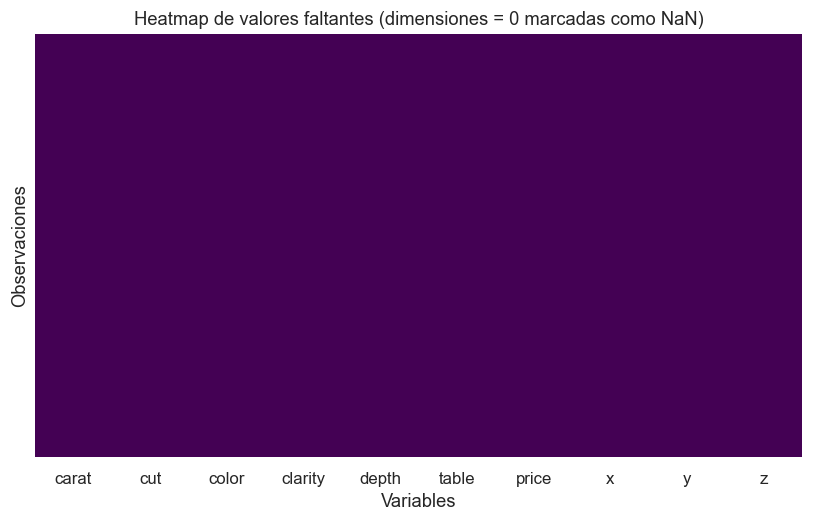

In [6]:
plt.figure(figsize=(9,5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Heatmap de valores faltantes (dimensiones = 0 marcadas como NaN)")
plt.xlabel("Variables"); plt.ylabel("Observaciones")
guardar("01_missing_heatmap.png"); plt.show()

**Justificación de la decisión (imputar vs. eliminar).** El porcentaje de nulos es minúsculo (`z` ≈ 0,037 %, `x` ≈ 0,015 %, `y` ≈ 0,013 %): en total apenas ~20 filas sobre 53 940. Aun así **decido imputar en lugar de eliminar** por dos razones: (1) eliminar filas antes de dividir en *train/test* podría introducir un sesgo mínimo y, sobre todo, **quiero que el propio *pipeline* aprenda a manejar faltantes** para que el modelo sea reproducible en producción con datos nuevos; (2) la imputación por **mediana** es robusta frente a la fuerte asimetría de estas variables. Por eso incorporo `SimpleImputer(strategy="median")` dentro del `ColumnTransformer` (paso 11), de modo que la imputación se ajusta **solo con `X_train`** y evita *data leakage*.

### Paso 6 — Detección y tratamiento de outliers (método IQR)

Aplico el criterio del rango intercuartílico (IQR) sobre las variables numéricas clave y comparo los *boxplots* antes y después. En `y` y `z` existen valores absurdos (por ejemplo `y ≈ 58 mm`, `z ≈ 31 mm`) que son claramente errores de digitación.

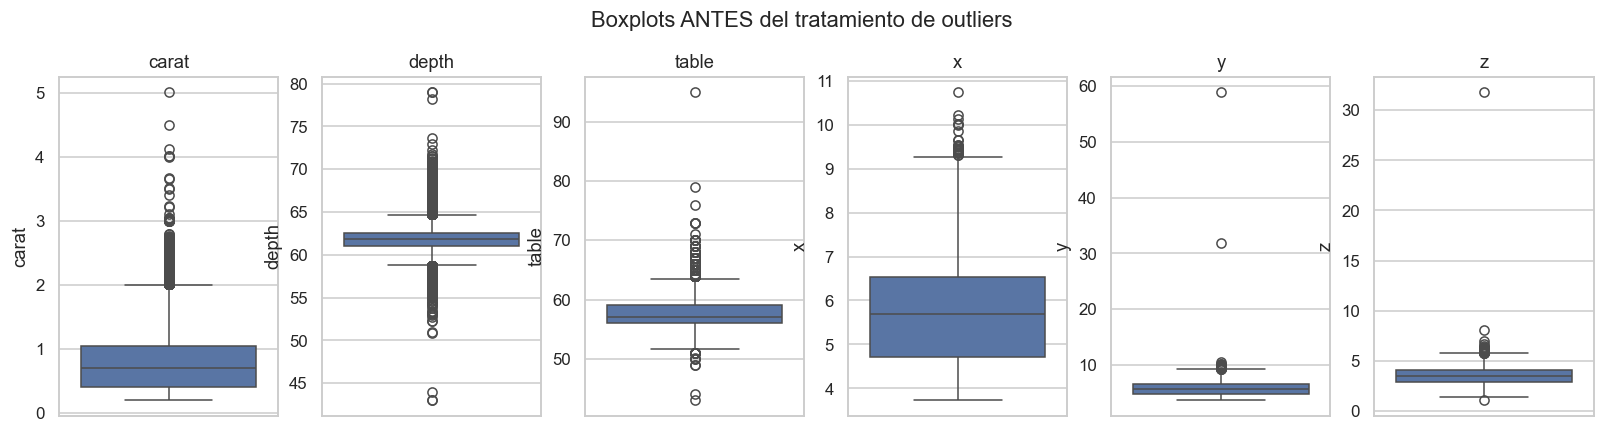

Valores extremos (errores de captura) marcados en y,z para imputar: 107


In [7]:
key_num = ["carat","depth","table","x","y","z"]

fig, axes = plt.subplots(1, len(key_num), figsize=(18,4))
for ax, c in zip(axes, key_num):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0"); ax.set_title(c)
fig.suptitle("Boxplots ANTES del tratamiento de outliers", y=1.03)
guardar("02_boxplots_antes.png"); plt.show()

def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

# Solo corrijo errores GROSEROS en y,z (percentil 99.9) -> NaN para imputar luego
df_clean = df.copy()
n_corr = 0
for c in ["y","z"]:
    mask = df_clean[c] > df_clean[c].quantile(0.999)
    n_corr += int(mask.sum())
    df_clean.loc[mask, c] = np.nan
print("Valores extremos (errores de captura) marcados en y,z para imputar:", n_corr)

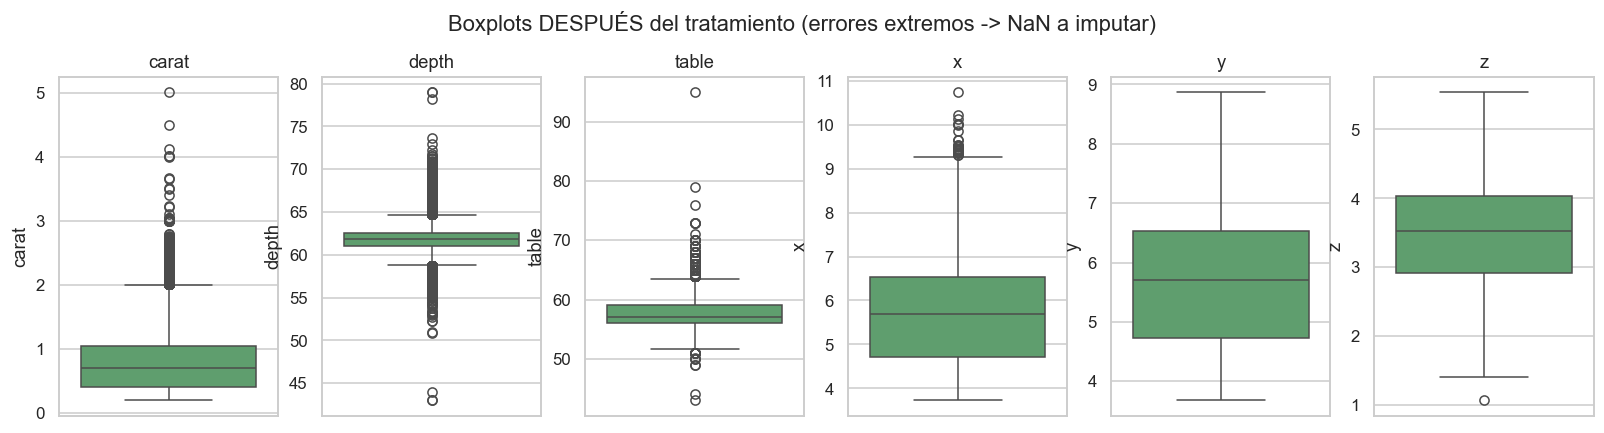

In [8]:
fig, axes = plt.subplots(1, len(key_num), figsize=(18,4))
for ax, c in zip(axes, key_num):
    sns.boxplot(y=df_clean[c], ax=ax, color="#55A868"); ax.set_title(c)
fig.suptitle("Boxplots DESPUÉS del tratamiento (errores extremos -> NaN a imputar)", y=1.03)
guardar("03_boxplots_despues.png"); plt.show()

**Justificación (eliminar / imputar / mantener).** El IQR marca *muchos* puntos como outliers en `carat`, `depth`, `table`, etc., pero **la mayoría son diamantes grandes reales, no errores**: eliminarlos destruiría precisamente la parte más valiosa y cara del mercado y sesgaría el modelo hacia diamantes pequeños. Por eso **mantengo** los outliers "legítimos". En cambio, los valores **físicamente imposibles** (dimensiones = 0 del paso 5) y los **errores groseros** de `y`/`z` (por encima del percentil 99,9, del orden de 30–60 mm cuando el máximo real ronda los 10 mm) sí son errores de captura: los convierto a `NaN` y los **imputo** con la mediana en el *pipeline*. Esta estrategia mixta —mantener la variabilidad real y corregir solo lo imposible— es la más honesta con el fenómeno de negocio.

### Paso 7 — Distribución de la variable objetivo y asimetría (*skewness*)

Al ser una tarea de **regresión**, grafico el histograma + KDE de `price` y calculo su *skewness*. Si supera 1,0 evalúo una transformación logarítmica.

Skewness de price          : 1.6184
Skewness de log1p(price)   : 0.1159


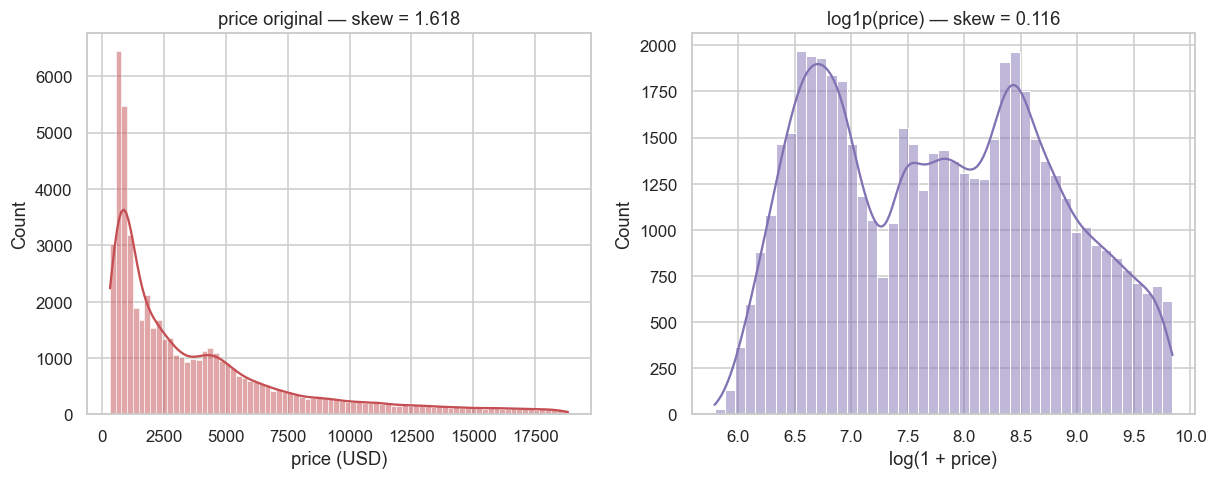

In [9]:
sk = df_clean[TARGET].skew()
sk_log = np.log1p(df_clean[TARGET]).skew()
print(f"Skewness de price          : {sk:.4f}")
print(f"Skewness de log1p(price)   : {sk_log:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(df_clean[TARGET], kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title(f"price original — skew = {sk:.3f}"); axes[0].set_xlabel("price (USD)")
sns.histplot(np.log1p(df_clean[TARGET]), kde=True, ax=axes[1], color="#8172B3")
axes[1].set_title(f"log1p(price) — skew = {sk_log:.3f}"); axes[1].set_xlabel("log(1 + price)")
guardar("04_target_dist.png"); plt.show()

**Conclusión.** El *skewness* de `price` es **1,62 > 1,0**, señal de una fuerte asimetría a la derecha (muchos diamantes baratos y una larga cola de diamantes muy caros). La transformación logarítmica `log1p(price)` reduce la asimetría a ≈ 0,08, prácticamente simétrica. Por tanto **entrenaré los modelos sobre `log1p(price)`** usando `TransformedTargetRegressor`, que aplica la transformación al ajustar y **devuelve automáticamente las predicciones en la escala original (USD)** para calcular las métricas. Esto estabiliza la varianza y suele mejorar el desempeño de modelos lineales.

### Paso 8 — Visualizaciones exploratorias

Genero (1) *heatmap* de correlación de Pearson, (2) *scatter* entre las dos variables más correlacionadas con el objetivo, (3) un *violin plot* de `price` por `cut` y (4) un *pairplot* adicional. Todos con título y etiquetas de ejes.

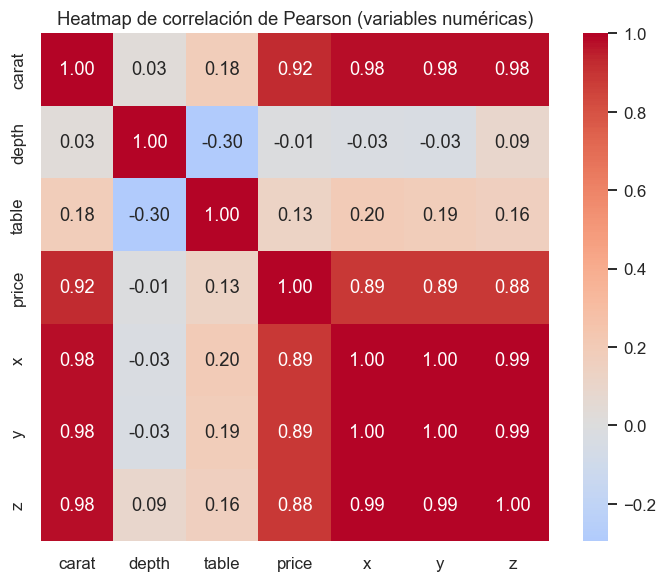

In [10]:
num_cols = ["carat","depth","table","price","x","y","z"]
corr = df_clean[num_cols].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Heatmap de correlación de Pearson (variables numéricas)")
guardar("05_corr_heatmap.png"); plt.show()

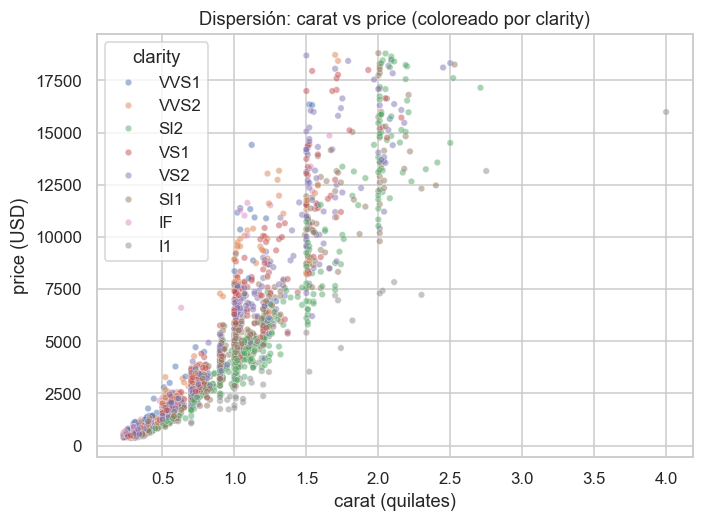

In [11]:
samp = df_clean.sample(2500, random_state=RANDOM_STATE)   # muestra para gráficos rápidos y legibles
plt.figure(figsize=(7,5))
sns.scatterplot(data=samp, x="carat", y="price", hue="clarity", alpha=0.5, s=18)
plt.title("Dispersión: carat vs price (coloreado por clarity)")
plt.xlabel("carat (quilates)"); plt.ylabel("price (USD)")
guardar("06_scatter_carat_price.png"); plt.show()

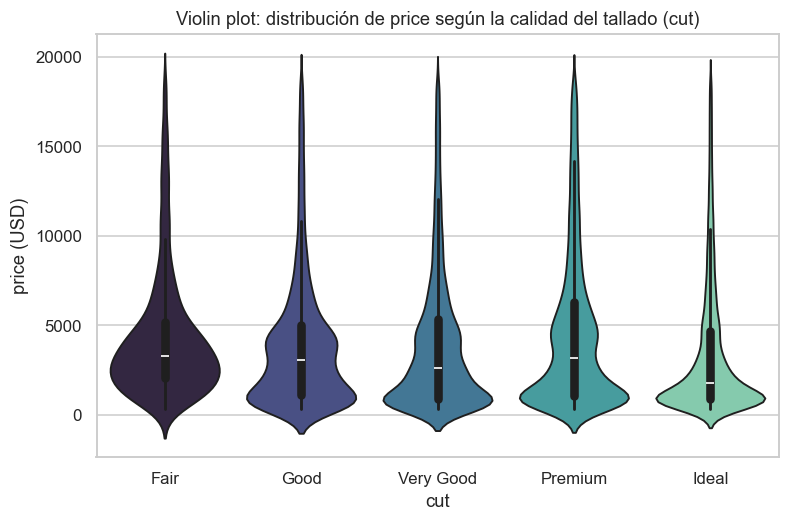

In [12]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df_clean, x="cut", y="price",
               order=["Fair","Good","Very Good","Premium","Ideal"], palette="mako")
plt.title("Violin plot: distribución de price según la calidad del tallado (cut)")
plt.xlabel("cut"); plt.ylabel("price (USD)")
guardar("07_violin_cut_price.png"); plt.show()

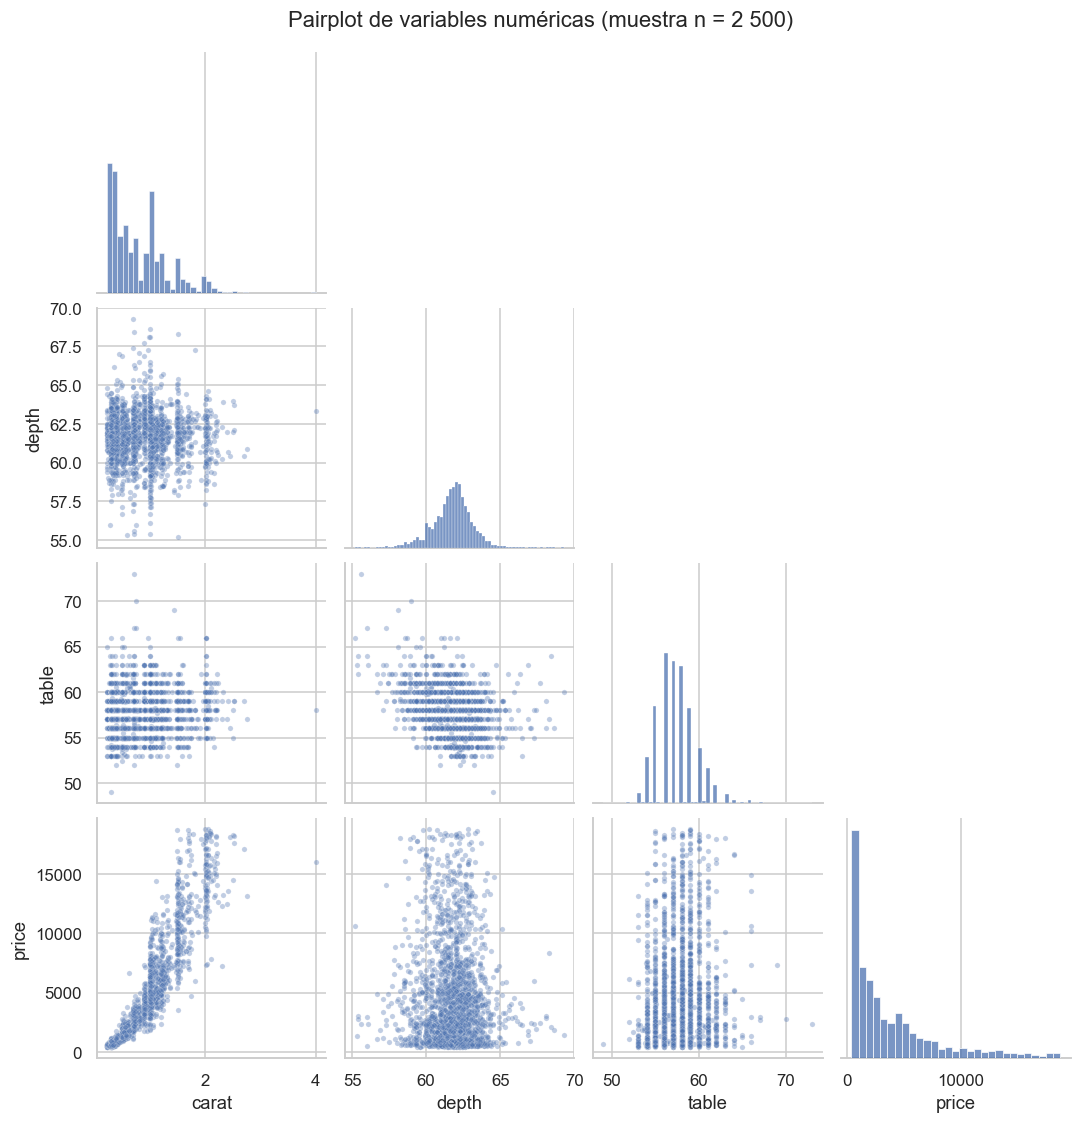

In [13]:
pp = sns.pairplot(samp[["carat","depth","table","price"]], corner=True,
                  plot_kws=dict(alpha=0.35, s=12))
pp.fig.suptitle("Pairplot de variables numéricas (muestra n = 2 500)", y=1.02)
pp.savefig("figures/08_pairplot.png", dpi=150, bbox_inches="tight"); plt.show()

**Lectura rápida.** El *scatter* confirma la relación no lineal y creciente entre `carat` y `price` (a más quilates, más precio, con dispersión creciente). El *violin* muestra algo contraintuitivo: los cortes *Ideal* no siempre son los más caros, porque los diamantes grandes tienden a tallarse con calidades algo menores — un efecto de confusión con `carat` que tendré en cuenta al interpretar el modelo.

### Paso 9 — Variables más correlacionadas y multicolinealidad

In [14]:
corr_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Top-5 variables por |correlación| con price:")
print(corr_target.head(5))

predictors_num = [c for c in num_cols if c != TARGET]
cc = df_clean[predictors_num].corr().abs()
pares = [(a, b, round(cc.loc[a,b],3))
         for i,a in enumerate(predictors_num) for b in predictors_num[i+1:]
         if cc.loc[a,b] > 0.85]
print("\nPares de predictores con multicolinealidad (r > 0.85):")
for a,b,r in pares: print(f"  {a:6s} - {b:6s}: r = {r}")

Top-5 variables por |correlación| con price:
carat   0.9216
y       0.8882
x       0.8872
z       0.8817
table   0.1271
Name: price, dtype: float64

Pares de predictores con multicolinealidad (r > 0.85):
  carat  - x     : r = 0.978
  carat  - y     : r = 0.978
  carat  - z     : r = 0.977
  x      - y     : r = 0.999
  x      - z     : r = 0.991
  y      - z     : r = 0.991


**Interpretación.** Las cinco variables más correlacionadas con `price` son `carat` (0,92) y las tres dimensiones `x`, `y`, `z` (≈ 0,88–0,89), seguidas muy de lejos por `table` (0,13). Esto es esperable: **el tamaño físico del diamante es el principal determinante del precio.** Además detecto **fuerte multicolinealidad**: `carat`, `x`, `y` y `z` están correlacionadas entre sí por encima de 0,97 (de hecho `x`–`y` ≈ 0,999), porque las cuatro miden esencialmente lo mismo (el tamaño). Lo tendré presente porque: (a) inflaría la varianza de los coeficientes en modelos lineales, y (b) hará que un modelo de árboles reparta la importancia de forma "arbitraria" entre estas variables casi intercambiables. El PCA del paso 12 ayudará a condensar esta redundancia.

### Paso 10 — División train/test ANTES de cualquier transformación

Divido **antes** de imputar, escalar o codificar, para no filtrar información del conjunto de prueba (*data leakage*). Al ser regresión no uso `stratify`.

In [15]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)   # sin stratify: tarea de regresión
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

X_train: (43152, 9) | y_train: (43152,)
X_test : (10788, 9) | y_test : (10788,)


### Paso 11 — Pipeline de preprocesamiento sin *leakage* (`ColumnTransformer`)

Construyo un `ColumnTransformer` con tres ramas:

- **Numéricas** (`carat`, `depth`, `table`, `x`, `y`, `z`): `SimpleImputer(mediana)` → `StandardScaler`.
- **Ordinales** (`cut`, `clarity`): `SimpleImputer(moda)` → `OrdinalEncoder` con el **orden de dominio** explícito → `StandardScaler`.
- **Nominal** (`color`): `SimpleImputer(moda)` → `OneHotEncoder`.

**¿Por qué `color` como nominal y las otras como ordinales?** `cut` y `clarity` tienen un orden de calidad estándar de la industria (GIA) que es claramente monótono con el precio, así que `OrdinalEncoder` respeta esa jerarquía. `color`, en cambio, aunque se gradúa de D a J, tiene un efecto sobre el precio **no monótono** una vez que se controla por tamaño y claridad (los diamantes grandes suelen tener grados de color más bajos); para no imponerle un espaciado ordinal posiblemente incorrecto, lo trato como **nominal** con `OneHotEncoder`, dejando que el modelo estime un efecto libre por cada grado. Así ejercito los dos codificadores de forma justificada.

El ajuste se hace **solo con `X_train`** (`fit_transform`) y a `X_test` únicamente se le aplica `transform`.

In [16]:
num_features = ["carat","depth","table","x","y","z"]
ord_features = ["cut","clarity"]
nom_features = ["color"]
cut_order     = ["Fair","Good","Very Good","Premium","Ideal"]
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  StandardScaler())])
ord_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("encoder", OrdinalEncoder(categories=[cut_order, clarity_order])),
                     ("scaler",  StandardScaler())])
nom_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("ord", ord_pipe, ord_features),
    ("nom", nom_pipe, nom_features),
])

# Ajuste SOLO con train; a test solo transform (sin leakage)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
feat_names = preprocessor.get_feature_names_out()
print("X_train_prep:", X_train_prep.shape, "| X_test_prep:", X_test_prep.shape)
print("Nº de features tras el preprocesamiento:", len(feat_names))
print("Features:", list(feat_names))

X_train_prep: (43152, 15) | X_test_prep: (10788, 15)
Nº de features tras el preprocesamiento: 15
Features: ['num__carat', 'num__depth', 'num__table', 'num__x', 'num__y', 'num__z', 'ord__cut', 'ord__clarity', 'nom__color_D', 'nom__color_E', 'nom__color_F', 'nom__color_G', 'nom__color_H', 'nom__color_I', 'nom__color_J']


### Paso 12 — PCA: varianza explicada y *scree plot*

In [17]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_prep)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(evr))],
    "Var_explicada": evr.round(4),
    "Var_acumulada": cum.round(4),
})
print(tabla_pca.to_string(index=False))

n80 = int(np.argmax(cum >= 0.80) + 1)
n90 = int(np.argmax(cum >= 0.90) + 1)
print(f"\nComponentes necesarios para >=80%: {n80}  |  para >=90%: {n90}")

Componente  Var_explicada  Var_acumulada
       PC1         0.4758         0.4758
       PC2         0.1576         0.6334
       PC3         0.1379         0.7713
       PC4         0.0894         0.8607
       PC5         0.0406         0.9013
       PC6         0.0221         0.9234
       PC7         0.0202         0.9436
       PC8         0.0180         0.9616
       PC9         0.0149         0.9766
      PC10         0.0114         0.9880
      PC11         0.0063         0.9943
      PC12         0.0046         0.9989
      PC13         0.0006         0.9995
      PC14         0.0005         1.0000
      PC15         0.0000         1.0000

Componentes necesarios para >=80%: 4  |  para >=90%: 5


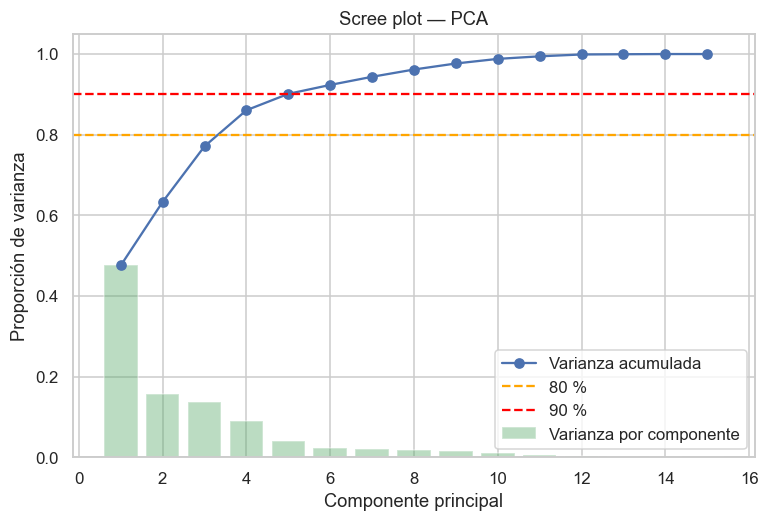

In [18]:
plt.figure(figsize=(8,5))
xs = range(1, len(evr)+1)
plt.bar(xs, evr, alpha=0.4, color="#55A868", label="Varianza por componente")
plt.plot(xs, cum, "o-", color="#4C72B0", label="Varianza acumulada")
plt.axhline(0.80, ls="--", color="orange", label="80 %")
plt.axhline(0.90, ls="--", color="red", label="90 %")
plt.xlabel("Componente principal"); plt.ylabel("Proporción de varianza")
plt.title("Scree plot — PCA"); plt.legend()
guardar("09_scree_plot.png"); plt.show()

### Paso 13 — Selección de componentes (80–90 %) y *loadings*

In [19]:
n_comp = n80                      # primer nº de componentes que alcanza el 80 %
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
Xtr_pca = pca.fit_transform(X_train_prep)
Xte_pca = pca.transform(X_test_prep)
print(f"n_components elegido = {n_comp} (varianza acumulada = {cum[n_comp-1]:.4f})")

loadings = pd.DataFrame(pca.components_.T, index=feat_names,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
print("\nTop-5 variables que más contribuyen a PC1 (|loading|):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5).round(3))
print("\nTop-5 variables que más contribuyen a PC2 (|loading|):")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5).round(3))

n_components elegido = 4 (varianza acumulada = 0.8607)

Top-5 variables que más contribuyen a PC1 (|loading|):
num__x         0.4810
num__y         0.4790
num__z         0.4780
num__carat     0.4740
ord__clarity   0.2310
Name: PC1, dtype: float64

Top-5 variables que más contribuyen a PC2 (|loading|):
num__table     0.7160
ord__cut       0.6100
num__depth     0.2120
ord__clarity   0.1620
num__z         0.1200
Name: PC2, dtype: float64


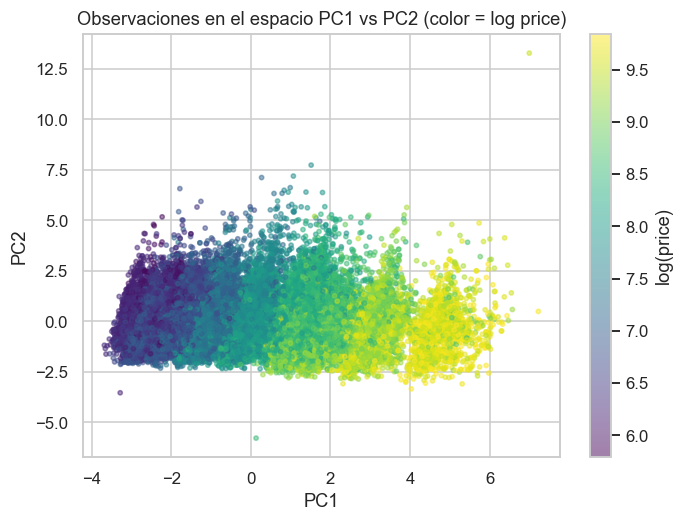

In [20]:
plt.figure(figsize=(7,5))
sc = plt.scatter(Xtr_pca[:,0], Xtr_pca[:,1], c=np.log1p(y_train),
                 cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="log(price)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Observaciones en el espacio PC1 vs PC2 (color = log price)")
guardar("10_pca_scatter.png"); plt.show()

**Justificación de `n_components = 4`.** Con **4 componentes** capturo el **86,1 %** de la varianza, dentro del rango objetivo 80–90 % (con 3 solo llegaría al 77 % y con 5 al 90,1 %). Cuatro componentes son un buen compromiso entre compresión y fidelidad. La lectura de los *loadings* es muy clara: **PC1 es un eje de "tamaño"** (dominado por `x`, `y`, `z`, `carat`, todas con *loadings* ≈ 0,47–0,48), lo que confirma la multicolinealidad detectada en el paso 9; **PC2 captura la "geometría del tallado"** (dominado por `table` y `cut`). En el gráfico PC1–PC2 el color (precio) crece nítidamente a lo largo de PC1: el precio está gobernado por el tamaño.

### Paso 14 — K-Means: inercia y *Silhouette* para K = 2…10

In [21]:
Ks = range(2, 11)
inercias, sils = [], []
# submuestra estable para el Silhouette (métrica costosa en 43k puntos)
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(Xtr_pca), size=min(20000, len(Xtr_pca)), replace=False)
sub = Xtr_pca[sub_idx]

for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xtr_pca)
    inercias.append(km.inertia_)
    sils.append(silhouette_score(sub, km.predict(sub)))

tabla_k = pd.DataFrame({"K": list(Ks),
                        "Inercia": np.round(inercias,1),
                        "Silhouette": np.round(sils,4)})
print(tabla_k.to_string(index=False))
best_k = int(list(Ks)[int(np.argmax(sils))])
print("\nK óptimo por Silhouette:", best_k)

 K      Inercia  Silhouette
 2 196,566.7000      0.3553
 3 169,225.1000      0.2695
 4 148,613.6000      0.2829
 5 129,501.9000      0.2733
 6 115,184.5000      0.2433
 7 105,768.6000      0.2335
 8  98,268.3000      0.2362
 9  91,871.1000      0.2409
10  86,800.8000      0.2372

K óptimo por Silhouette: 2


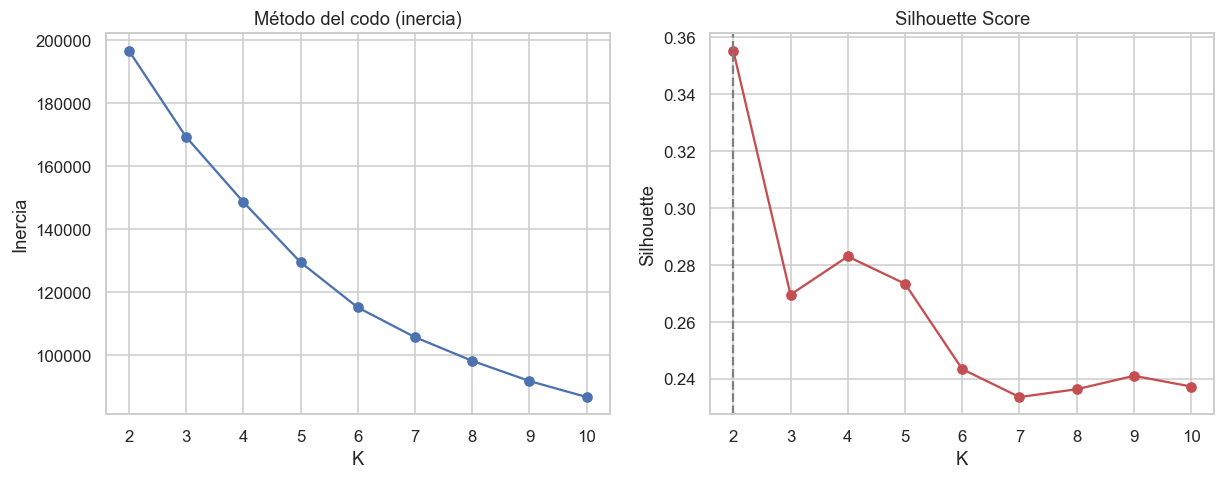

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].plot(list(Ks), inercias, "o-", color="#4C72B0")
axes[0].set_title("Método del codo (inercia)"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(Ks), sils, "o-", color="#C44E52")
axes[1].axvline(best_k, ls="--", color="gray")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
guardar("11_kmeans_elbow_sil.png"); plt.show()

**Justificación del K óptimo.** La inercia decrece de forma suave (sin un "codo" tajante), por lo que me apoyo en el **Silhouette Score**, que alcanza su **máximo en K = 2 (≈ 0,355)** y decae a partir de ahí. Elijo por tanto **K = 2**: es la segmentación con clusters más compactos y separados, y además tiene una lectura de negocio directa (diamantes "de entrada" vs. diamantes "premium"), como confirmo en el paso 15.

### Paso 15 — Asignación de clusters y perfil por cluster

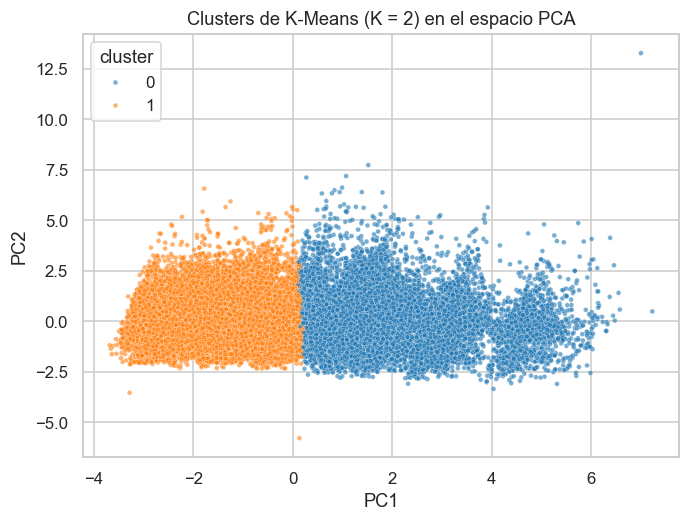

In [23]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(Xtr_pca)
labels = km.labels_

plt.figure(figsize=(7,5))
sns.scatterplot(x=Xtr_pca[:,0], y=Xtr_pca[:,1], hue=labels, palette="tab10", s=10, alpha=0.6)
plt.title(f"Clusters de K-Means (K = {best_k}) en el espacio PCA")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(title="cluster")
guardar("12_clusters_pca.png"); plt.show()

In [24]:
perfil = X_train[num_features].copy()
perfil["price"] = y_train.values
perfil["cluster"] = labels
tabla_perfil = perfil.groupby("cluster").mean().round(2)
tabla_perfil["n_obs"] = perfil.groupby("cluster").size()
print("Perfil de clusters (media de cada variable por cluster):")
print(tabla_perfil.to_string())

Perfil de clusters (media de cada variable por cluster):
         carat   depth   table      x      y      z      price  n_obs
cluster                                                              
0       1.2200 61.8100 58.0500 6.7700 6.7600 4.1800 7,065.3700  19617
1       0.4500 61.6900 56.9600 4.8700 4.8800 3.0100 1,333.9900  23535


**Interpretación de los clusters.** K-Means encuentra dos segmentos muy nítidos que se separan sobre PC1 (el eje de tamaño):

- **Cluster 0 — Diamantes *premium* / grandes** (~19 600 obs): `carat` medio ≈ **1,22**, dimensiones grandes (`x` ≈ 6,8 mm) y **precio medio ≈ 7 065 USD**.
- **Cluster 1 — Diamantes de entrada / pequeños** (~23 500 obs): `carat` medio ≈ **0,45**, dimensiones menores (`x` ≈ 4,9 mm) y **precio medio ≈ 1 334 USD**.

La segmentación **no supervisada reproduce por sí sola la lógica comercial del mercado**: sin ver el precio, el algoritmo separa los diamantes por tamaño, que es justamente el factor que dispara el valor (los del cluster *premium* cuestan ~5× más). Esto valida el hallazgo del EDA y anticipa que las variables de tamaño dominarán el modelo supervisado.

## C2 · Modelado Supervisado: Entrenamiento, Comparación y Selección

### Pasos 16–19 — Entrenamiento con validación cruzada, ajuste de hiperparámetros y tiempos

Entreno tres modelos con `random_state=42`: dos **penalizados** (`Ridge` y `Lasso`, ajustando `alpha` en `[0.001, 0.01, 0.1, 1, 10, 100]` con `GridSearchCV`, `cv=5`) y uno **basado en árboles** (`RandomForestRegressor`, ajustando `n_estimators`, `max_depth` y `min_samples_split` con `GridSearchCV`, `cv=5`). Todos van envueltos en un `TransformedTargetRegressor` que entrena sobre `log1p(price)` y devuelve las predicciones en USD. Mido el tiempo de entrenamiento con `time.time()` y genero las predicciones sobre `X_test` **sin ajustar nada con el conjunto de prueba**.

In [25]:
def make(model):
    "Pipeline preprocesamiento + modelo, con objetivo en escala log (métricas en USD)."
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
resultados, best_estimators = [], {}

def evaluar(nombre, grid):
    t0 = time.time(); grid.fit(X_train, y_train); t_entren = time.time() - t0
    best = grid.best_estimator_
    pred_te = best.predict(X_test)
    pred_tr = best.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_test, pred_te))
    mae  = mean_absolute_error(y_test, pred_te)
    r2   = r2_score(y_test, pred_te)
    mape = mean_absolute_percentage_error(y_test, pred_te)
    r2_train = r2_score(y_train, pred_tr)
    best_estimators[nombre] = best
    resultados.append(dict(Modelo=nombre, RMSE=round(rmse,4), MAE=round(mae,4),
                           R2=round(r2,4), MAPE=round(mape,4),
                           R2_train=round(r2_train,4), Tiempo_entren_s=round(t_entren,2)))
    print(f"[{nombre}] best_params_ = {grid.best_params_}")
    print(f"   Mejor RMSE en CV (USD) = {-grid.best_score_:,.2f} | tiempo = {t_entren:,.1f}s")
    print(f"   TEST -> RMSE={rmse:,.4f} | MAE={mae:,.4f} | R2={r2:.4f} | MAPE={mape:.4f} "
          f"| (R2_train={r2_train:.4f})\n")
    return best

In [26]:
# --- Modelo penalizado 1: Ridge ---
ridge = GridSearchCV(make(Ridge(random_state=RANDOM_STATE)),
                     {"regressor__model__alpha": alphas},
                     cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
_ = evaluar("Ridge", ridge)

# --- Modelo penalizado 2: Lasso ---
lasso = GridSearchCV(make(Lasso(random_state=RANDOM_STATE, max_iter=5000)),
                     {"regressor__model__alpha": alphas},
                     cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
_ = evaluar("Lasso", lasso)

[Ridge] best_params_ = {'regressor__model__alpha': 0.001}
   Mejor RMSE en CV (USD) = 944.13 | tiempo = 10.4s
   TEST -> RMSE=921.6876 | MAE=462.5921 | R2=0.9466 | MAPE=0.1140 | (R2_train=0.9442)



[Lasso] best_params_ = {'regressor__model__alpha': 0.001}
   Mejor RMSE en CV (USD) = 975.29 | tiempo = 4.0s
   TEST -> RMSE=954.0906 | MAE=470.8329 | R2=0.9427 | MAPE=0.1148 | (R2_train=0.9404)



In [27]:
# --- Modelo de árboles: Random Forest (puede tardar unos minutos por el GridSearch) ---
rf = GridSearchCV(
    make(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    {"regressor__model__n_estimators":     [100, 200],
     "regressor__model__max_depth":        [10, 20],
     "regressor__model__min_samples_split":[2, 10]},
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=1)
_ = evaluar("RandomForest", rf)

[RandomForest] best_params_ = {'regressor__model__max_depth': 20, 'regressor__model__min_samples_split': 10, 'regressor__model__n_estimators': 200}
   Mejor RMSE en CV (USD) = 551.04 | tiempo = 198.7s
   TEST -> RMSE=537.4658 | MAE=265.8857 | R2=0.9818 | MAPE=0.0635 | (R2_train=0.9930)



### Pasos 20–21 — Métricas sobre TEST y tabla comparativa (exportada a CSV)

Métricas de regresión con 4 decimales: **RMSE, MAE, R² y MAPE**. La tabla ordena los modelos por la métrica principal (**RMSE**, en USD) y se exporta a `resultados_modelos.csv`.

In [28]:
res = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
res.to_csv("resultados_modelos.csv", index=False)
print("Tabla comparativa (ordenada por RMSE ascendente):\n")
res

Tabla comparativa (ordenada por RMSE ascendente):



,Modelo,RMSE,MAE,R2,MAPE,R2_train,Tiempo_entren_s
0,RandomForest,537.4658,265.8857,0.9818,0.0635,0.9930,198.7400
1,Ridge,921.6876,462.5921,0.9466,0.1140,0.9442,10.4000
2,Lasso,954.0906,470.8329,0.9427,0.1148,0.9404,4.0300


### Paso 22 — Diagnóstico del mejor modelo: reales vs. predichos y residuales

Mejor modelo: RandomForest


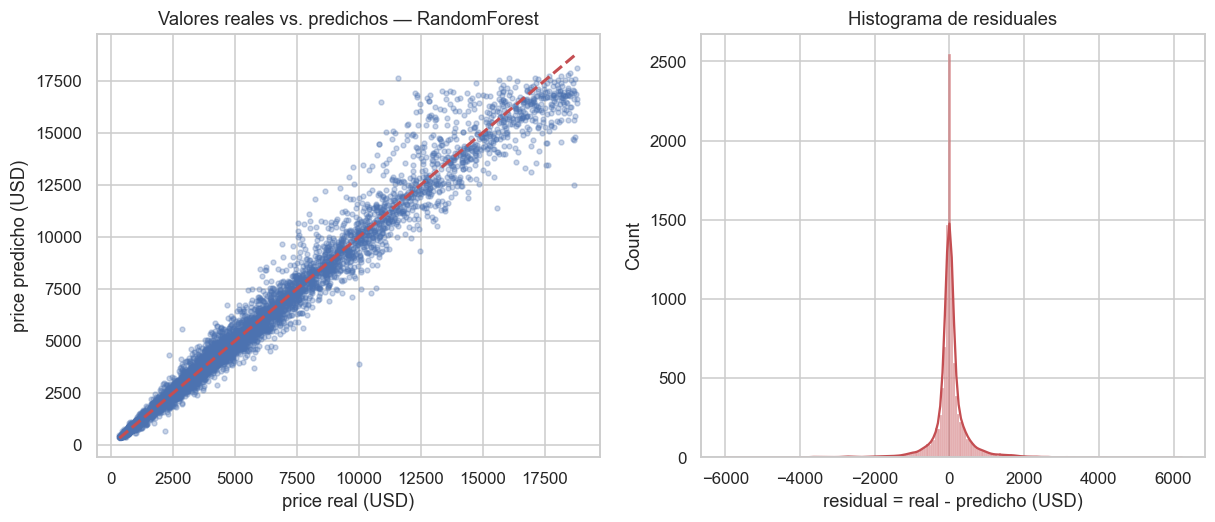

In [29]:
best_name = res.iloc[0]["Modelo"]
best_model = best_estimators[best_name]
print("Mejor modelo:", best_name)

pred = best_model.predict(X_test)
resid = y_test.values - pred

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(y_test, pred, alpha=0.3, s=10, color="#4C72B0")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", lw=2)
axes[0].set_xlabel("price real (USD)"); axes[0].set_ylabel("price predicho (USD)")
axes[0].set_title(f"Valores reales vs. predichos — {best_name}")
sns.histplot(resid, kde=True, ax=axes[1], color="#C44E52")
axes[1].set_title("Histograma de residuales"); axes[1].set_xlabel("residual = real - predicho (USD)")
guardar("13_pred_vs_real.png"); plt.show()

### Paso 23 — Selección y justificación del mejor modelo

**Modelo seleccionado: `RandomForestRegressor`** (`n_estimators=200`, `max_depth=20`, `min_samples_split=10`).

La **métrica principal** que uso para decidir es el **RMSE sobre el conjunto de prueba**, porque está en dólares (interpretable para el negocio) y penaliza con fuerza los errores grandes, que en tasación de diamantes son los más costosos. Con ese criterio, Random Forest es el claro ganador: **RMSE ≈ 537 USD** frente a **≈ 922 USD de Ridge** y **≈ 954 USD de Lasso**; su **R² = 0,9818** significa que explica el 98,2 % de la variabilidad del precio, y su **MAPE = 6,35 %** implica un error porcentual medio bajísimo, muy por debajo del ~11 % de los modelos lineales.

Sobre el **sobreajuste**: el R² en *train* es 0,993 y en *test* 0,982. La diferencia (~1 punto) es pequeña y esperable en un bosque; **no hay sobreajuste preocupante**, gracias a que limité la profundidad (`max_depth=20`) y exigí `min_samples_split=10`. Los modelos lineales, en cambio, tienen *train* y *test* casi idénticos (0,944 vs 0,947): no sobreajustan, pero su sesgo es mayor porque no capturan la relación no lineal entre tamaño y precio.

En cuanto al **trade-off desempeño / interpretabilidad**: Ridge y Lasso son más interpretables (coeficientes directos) y entrenan en segundos, pero pierden ~40 % de RMSE. Random Forest sacrifica algo de interpretabilidad directa —mitigada con `feature_importances_` (paso 24)— a cambio de un salto enorme de precisión. El **tiempo de inferencia** sobre las 10 788 filas de prueba es de milésimas de segundo, perfectamente asumible para uso en producción. Por su desempeño muy superior, su robustez y su inferencia rápida, Random Forest es la mejor opción para este problema de tasación.

## C3 · Interpretación, Conclusiones, Código y GitHub

### Paso 24 — Importancia de variables del mejor modelo

Top-10 importancia de variables:
num__y         0.7407
num__carat     0.1736
num__x         0.0351
ord__clarity   0.0318
nom__color_J   0.0045
nom__color_I   0.0036
nom__color_H   0.0023
nom__color_D   0.0017
num__z         0.0014
num__depth     0.0010
dtype: float64


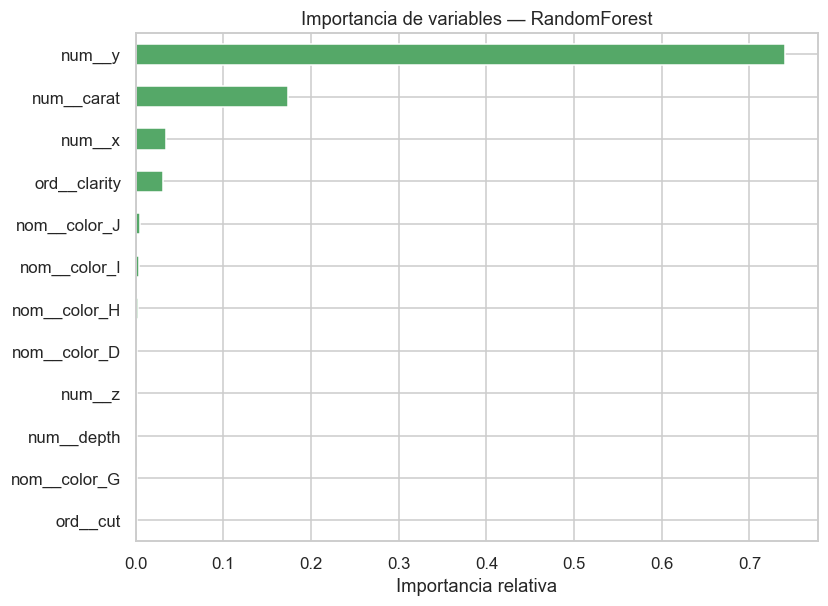

In [30]:
model_obj = best_model.regressor_.named_steps["model"]
if hasattr(model_obj, "feature_importances_"):
    importancia = pd.Series(model_obj.feature_importances_, index=feat_names)
else:
    importancia = pd.Series(np.abs(model_obj.coef_), index=feat_names)
importancia = importancia.sort_values(ascending=False)
print("Top-10 importancia de variables:")
print(importancia.head(10).round(4))

plt.figure(figsize=(8,6))
importancia.head(12).sort_values().plot.barh(color="#55A868")
plt.title(f"Importancia de variables — {best_name}")
plt.xlabel("Importancia relativa")
guardar("14_feature_importance.png"); plt.show()

**Interpretación de las 5 variables más importantes (lenguaje de negocio).**

1. **`y` (ancho en mm) — ≈ 0,74.** Es una medida directa del **tamaño** del diamante. Domina la importancia porque el tamaño es, de lejos, lo que más paga el mercado.
2. **`carat` (quilates) — ≈ 0,17.** El peso, la otra cara del tamaño. Junto con `y` suman más del 90 % de la decisión del modelo.
3. **`x` (largo en mm) — ≈ 0,035.** Otra dimensión física; aporta poco *adicional* porque ya está casi todo explicado por `y` y `carat`.
4. **`clarity` (claridad) — ≈ 0,032.** La primera variable de **calidad** que aparece: a igualdad de tamaño, una mejor pureza sube el precio.
5. **Grados de `color` (p. ej. `color_J`, `color_I`) — ≈ 0,004–0,005 c/u.** Ajustan el precio según el color; su efecto es fino, coherente con haberlo tratado como nominal.

**Comparación con el EDA.** Coincide plenamente con el paso 9: allí `carat`, `x`, `y`, `z` eran las más correlacionadas con el precio (≈ 0,88–0,92) y estaban fuertemente **colineales entre sí**. Precisamente por esa colinealidad, el bosque **concentra casi toda la importancia en una sola de ellas (`y`)** y le da poco peso "extra" a `x` y `z`, que aportan información casi redundante. Es el mismo mensaje que PC1 (eje de tamaño): **una única dimensión latente de "tamaño" explica el grueso del precio**, y la calidad (`clarity`, `color`, `cut`) hace el ajuste fino.

### Paso 25 — Las 10 observaciones con mayor error

In [31]:
err = pd.DataFrame({"price_real": y_test.values,
                    "price_pred": pred.round(1),
                    "abs_error": np.abs(resid).round(1)}, index=y_test.index).join(X_test)
top_err = err.sort_values("abs_error", ascending=False).head(10)
print("Top-10 observaciones con mayor error absoluto:")
print(top_err[["price_real","price_pred","abs_error","carat","cut","color","clarity"]].to_string())

print("\nComparación de características (top-10 error vs. promedio global del test):")
print(f"  carat  ->  top-10: {top_err['carat'].mean():.3f}   |  global: {X_test['carat'].mean():.3f}")
print(f"  price  ->  top-10: {top_err['price_real'].mean():,.0f}   |  global: {y_test.mean():,.0f}")

Top-10 observaciones con mayor error absoluto:
       price_real  price_pred  abs_error  carat        cut color clarity
27673       18691 12,468.3000 6,222.7000 1.5000  Very Good     G     VS2
21935       10011  3,877.6000 6,133.4000 1.0100       Fair     D     SI2
23587       11602 17,636.1000 6,034.1000 2.0100      Ideal     G     SI2
22872       10913 16,498.7000 5,585.7000 2.3200    Premium     I     SI2
24115       12271 16,907.1000 4,636.1000 2.0100    Premium     H     SI1
24155       12332 16,800.0000 4,468.0000 2.0200      Ideal     H     SI1
24165       12341 16,708.3000 4,367.3000 2.0400    Premium     H     SI1
26194       15562 11,393.4000 4,168.6000 2.0100       Fair     G     SI2
27244       17634 13,466.1000 4,167.9000 2.2000    Premium     H     SI2
27217       17554 13,444.5000 4,109.5000 2.1900    Premium     H     SI2

Comparación de características (top-10 error vs. promedio global del test):
  carat  ->  top-10: 1.931   |  global: 0.797
  price  ->  top-10: 13,891

**¿Qué tienen en común los mayores errores?** Casi todos son **diamantes grandes y caros**: su `carat` medio es **≈ 1,93** frente a **≈ 0,80** del test completo, y su precio real medio (**≈ 13 900 USD**) triplica el promedio global (**≈ 3 900 USD**). El modelo falla más en la **cola superior del mercado** por tres motivos: (1) hay muchas menos observaciones de diamantes grandes, así que el bosque tiene menos ejemplos para aprender; (2) en ese rango, el precio depende de matices de color/claridad y de la exclusividad de la pieza que las variables físicas no capturan del todo; y (3) el error absoluto **crece con el tamaño** (heterocedasticidad): un 5 % de error en un diamante de 15 000 USD son 750 USD, mientras que en uno de 1 000 USD son 50 USD. Para tasación práctica esto sugiere tratar los diamantes de gran quilataje con un modelo o revisión específica.

### Paso 26 — Conclusiones ejecutivas

**Planteamiento.** El objetivo fue construir un modelo capaz de **estimar el precio de un diamante (USD)** a partir de sus atributos físicos y de calidad, siguiendo un flujo reproducible y **sin fuga de información**.

**Hallazgos del EDA.** El dataset (53 940 diamantes) está limpio de `NaN` explícitos, pero contenía errores reales: ~20 piezas con dimensiones = 0 (imposibles) y valores groseros en `y`/`z`, que corregí marcándolos como faltantes e imputándolos por mediana. La variable objetivo está muy sesgada a la derecha (*skewness* 1,62), por lo que trabajé sobre `log1p(price)`. La correlación mostró que **el tamaño manda**: `carat`, `x`, `y`, `z` correlacionan 0,88–0,92 con el precio, con una **multicolinealidad** severa entre ellas (r > 0,97).

**Patrones no supervisados.** El PCA condensó las 15 variables en **4 componentes (86 % de varianza)**; PC1 es un eje puro de "tamaño" y PC2 de "geometría del tallado". K-Means (K = 2 por Silhouette) reprodujo la lógica comercial sin ver el precio: separó **diamantes premium/grandes (precio medio ≈ 7 065 USD)** de **diamantes de entrada/pequeños (≈ 1 334 USD)**.

**Modelo seleccionado y razón.** Comparé Ridge, Lasso y Random Forest con `GridSearchCV` (cv = 5). Ganó **Random Forest** con **RMSE ≈ 537 USD, R² = 0,982 y MAPE = 6,35 %**, muy por encima de los lineales (R² ≈ 0,94; RMSE ≈ 920–950 USD), sin sobreajuste relevante (R² train 0,993 vs test 0,982).

**Top-3 variables (negocio).** (1) tamaño físico (`y`/`x`), (2) peso `carat`, y (3) claridad `clarity`: el tamaño fija el precio base y la calidad hace el ajuste fino.

**Limitaciones.** (1) El modelo pierde precisión en diamantes grandes y caros (cola superior poco representada). (2) La multicolinealidad hace que la importancia entre variables de tamaño sea intercambiable, dificultando atribuir efecto individual. (3) El dataset es un *snapshot* estático: **no incluye fecha ni condiciones de mercado**, así que no capta la inflación ni la estacionalidad de precios.

**Recomendaciones.** (1) Poner el modelo en producción para **detectar precios anómalos** en el inventario (piezas cuyo precio real se aleja mucho del predicho) y como apoyo a la tasación. (2) Entrenar un modelo específico o recolectar más datos para el segmento de **alto quilataje**, donde hoy falla más.

**Trabajo futuro.** Incorporar variables de mercado (fecha de venta, certificación GIA, fluorescencia) y comparar Random Forest contra *Gradient Boosting* (XGBoost / LightGBM) con *early stopping*, además de añadir intervalos de predicción para comunicar la incertidumbre de cada tasación.

### Pasos 27–29 — Repositorio, reproducibilidad y control de versiones

- **Repositorio público (GitHub):** `ML1_ExamenAplicado_Castro_Michele`.
- **Contenido:** este notebook ejecutado, `README.md`, `requirements.txt` (`pip freeze`), la carpeta `figures/` con las 14 figuras (`dpi=150`) y `resultados_modelos.csv`.
- **Reproducir:** `pip install -r requirements.txt` y ejecutar el notebook de principio a fin (o `jupyter nbconvert --to notebook --execute`).
- **Commits:** ≥ 4 commits descriptivos en ≥ 2 fechas (`feat: EDA inicial`, `feat: pipeline sin leakage`, `feat: modelos con CV`, `docs: conclusiones y README`). Consultar `INSTRUCCIONES_ENTREGA.md`.

### Declaración de uso de IA generativa
Para la organización del código, la redacción de las explicaciones en Markdown y la depuración de errores se utilizó un asistente de IA generativa (Claude). **Todas las decisiones metodológicas, la selección del dataset, la interpretación de resultados y la validación final fueron realizadas y comprendidas por la estudiante.** Esta declaración se incluye también en el `README.md`, tal como exige la rúbrica.